In [20]:
from helpers import (
    get_retriever,
    load_pdf_document,
    get_connection,
    invoke_chain,
    get_embeddings,
    compare_chains_based_on_question,
    load_questions,
    create_graph,
    validate_answer
)
from langchain.chains import FlareChain, RetrievalQA, GraphQAChain

In [24]:
llm = get_connection()
documents = load_pdf_document(file_path="data/inputs/deeplearningbook.pdf", start_page=15, end_page=17)
embeddings = get_embeddings()
retriever = get_retriever(documents=documents, embeddings=embeddings)

Number of Document objects before recursive splitting: 2
Number of Document objects after recursive splitting: 31


In [26]:
documents

[Document(page_content='Chapter 1\nIntroduction\nInventors have long dreamed of creating machines that think. This desire dates\nback to at least the time of ancient Greece. The mythical figures Pygmalion,\nDaedalus, and Hephaestus may all be interpreted as legendary inventors, and\nGalatea, Talos, and Pandora may all be regarded as artificial life (Ovid and Martin,\n2004; Sparkes, 1996; Tandy, 1997).\nWhen programmable computers were first conceived, people wondered whether\nsuch machines might become intelligent, over a hundred years before one was\nbuilt (Lovelace, 1842). Today, artificial intelligence (AI) is a thriving field with\nmany practical applications and active research topics. We look to intelligent\nsoftware to automate routine labor, understand speech or images, make diagnoses\nin medicine and support basic scientific research.\nIn the early days of artificial intelligence, the field rapidly tackled and solved\nproblems that are intellectually difficult for human beings

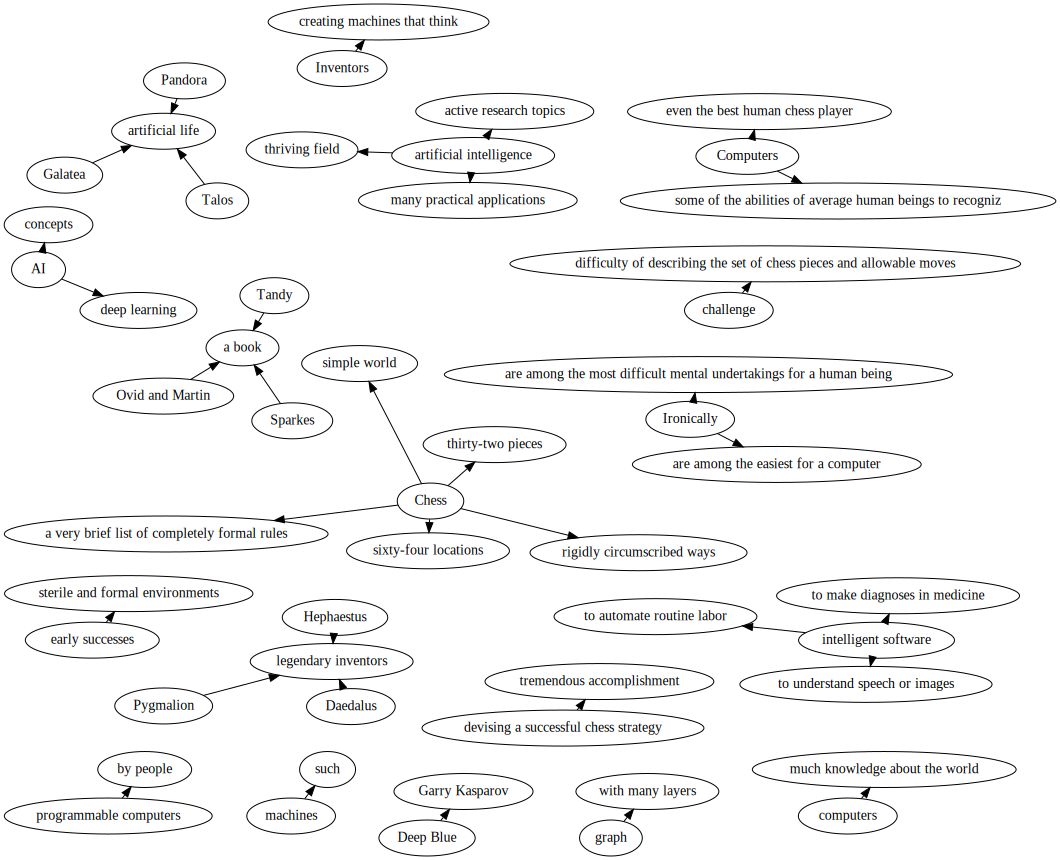

In [27]:
graph = create_graph(llm=llm, documents=documents)
from IPython.display import SVG
graph.draw_graphviz(path="data/outputs/graph.svg", prog='fdp')
SVG("data/outputs/graph.svg")

In [42]:
flare_chain = FlareChain.from_llm(
    llm=llm, retriever=retriever, max_generation_len=200, min_prob=0.6, max_iter=2, verbose=True
)
retrieval_chain = RetrievalQA.from_llm(llm=llm, retriever=retriever, verbose=True)
graph_chain = GraphQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    verbose=True
)
questions = load_questions(file_path="data/inputs/questions.txt")
questions

['What is Deep Blue?',
 'Who is Hephaestus?',
 'Which were challenges in the early days of artificial intelligence?']

In [38]:
compare_chains_based_on_question(
    chains=[retrieval_chain, flare_chain, graph_chain],
    labels=["RetrievalQA", "FLARE", "GraphQA"],
    embeddings=embeddings,
    question=questions[0],
)

Starting comparison for following question: What is Deep Blue?


> Entering new RetrievalQA chain...

> Finished chain.
For chain RetrievalQA was provided following answer:
 Deep Blue is a chess-playing system created by IBM that defeated world champion Garry Kasparov in 1997.
Cosine Similarity: 0.621
Euclidean Distance: 0.870



> Entering new FlareChain chain...
Current Response: 
Prompt after formatting:
Respond to the user message using any relevant context. If context is provided, you should ground your answer in that context. Once you're done responding return FINISHED.

>>> CONTEXT: 
>>> USER INPUT: What is Deep Blue?
>>> RESPONSE: 
Generated Questions: [' What is Deep Blue best known for?', ' "What is Deep Blue most famous for?"']
Current Response:  Deep Blue was a chess-playing system created by IBM that famously defeated world champion Garry Kasparov in 1997. It was one of the early examples of using knowledge-based approaches to artificial intelligence, but it did not lead t

In [41]:
compare_chains_based_on_question(
    chains=[retrieval_chain, flare_chain, graph_chain],
    labels=["RetrievalQA", "FLARE", "GraphQA"],
    embeddings=embeddings,
    question=questions[1],
)

Starting comparison for following question: Who is Hephaestus?


> Entering new RetrievalQA chain...

> Finished chain.
For chain RetrievalQA was provided following answer:

Hephaestus is a legendary inventor in Greek mythology.
Cosine Similarity: 0.802
Euclidean Distance: 0.629



> Entering new FlareChain chain...
Current Response: 
Prompt after formatting:
Respond to the user message using any relevant context. If context is provided, you should ground your answer in that context. Once you're done responding return FINISHED.

>>> CONTEXT: 
>>> USER INPUT: Who is Hephaestus?
>>> RESPONSE: 
Generated Questions: [' "What is Hephaestus known for as a Greek god?"', ' "What is Hephaestus known for creating as a god?"', ' What is Hephaestus known for creating for the gods and heroes?', ' What is Hephaestus known for creating for the gods and heroes?', ' Who is Hephaestus married to?']
Current Response:  Hephaestus is a legendary inventor in Greek mythology, known for creating many ingeniou

In [43]:
compare_chains_based_on_question(
    chains=[retrieval_chain, flare_chain, graph_chain],
    labels=["RetrievalQA", "FLARE", "GraphQA"],
    embeddings=embeddings,
    question=questions[2],
)

Starting comparison for following question: Which were challenges in the early days of artificial intelligence?


> Entering new RetrievalQA chain...

> Finished chain.
For chain RetrievalQA was provided following answer:

Some challenges in the early days of artificial intelligence included solving intellectually difficult problems, operating in sterile and formal environments, and lacking knowledge about the world.
Cosine Similarity: 0.761
Euclidean Distance: 0.691



> Entering new FlareChain chain...
Current Response: 
Prompt after formatting:
Respond to the user message using any relevant context. If context is provided, you should ground your answer in that context. Once you're done responding return FINISHED.

>>> CONTEXT: 
>>> USER INPUT: Which were challenges in the early days of artificial intelligence?
>>> RESPONSE: 
Generated Questions: [' What were some of the main challenges in the early days of artificial intelligence?', ' What were some of the main limitations in the ea